# Clustering Analysis

This notebook keeps the label out of the feature matrix during clustering.

## Methods

- `GMM`: cluster the dense low-dimensional embedding.
- `Community detection`: build a k-NN graph on a sample and run modularity-based community detection.
- `UMAP` and `t-SNE`: visualize the clustered embedding.

Because graph clustering and `t-SNE` are expensive on ~200k rows, the notebook uses a reproducible sample for those parts.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import umap.umap_ as umap
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import kneighbors_graph
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cols = [x.strip() for x in open('census-bureau.columns') if x.strip()]
df = pd.read_csv('census-bureau.data', header=None, names=cols, na_values='?')
target_col = cols[-1]
X = df.drop(columns=target_col).copy()

categorical_codes = [
    'detailed industry recode',
    'detailed occupation recode',
    'own business or self employed',
    'veterans benefits',
    'year',
]
cat_cols = list(X.select_dtypes(include='object').columns) + categorical_codes
cat_cols = list(dict.fromkeys(cat_cols))
num_cols = [c for c in X.columns if c not in cat_cols]

money_cols = ['wage per hour', 'capital gains', 'capital losses', 'dividends from stocks']
X = X.assign(**{c: np.log1p(X[c].astype('float32')) for c in money_cols})

/home/lhuang37/.conda/envs/census-cluster/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_3265725/2768976015.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = list(X.select_dtypes(include='object').columns) + categorical_codes


In [2]:
pre = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), num_cols),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='constant', fill_value='Missing')),
        ('ohe', OneHotEncoder(handle_unknown='ignore')),
    ]), cat_cols),
], sparse_threshold=1.0)

z = pre.fit_transform(X)
embed = TruncatedSVD(n_components=64, random_state=42).fit_transform(z)
embed = StandardScaler().fit_transform(embed)

rng = np.random.default_rng(42)
sample_n = 20000
sample_idx = rng.choice(len(embed), sample_n, replace=False)
embed_sample = embed[sample_idx]

In [3]:
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm_labels = gmm.fit_predict(embed)
gmm_labels_sample = gmm_labels[sample_idx]

A = kneighbors_graph(embed_sample, n_neighbors=20, mode='connectivity', include_self=False)
G = nx.from_scipy_sparse_array(A.maximum(A.T))
communities = list(nx.community.greedy_modularity_communities(G))
community_labels = np.empty(sample_n, dtype=int)
for i, nodes in enumerate(communities):
    community_labels[list(nodes)] = i

summary = pd.DataFrame([
    {
        'method': 'GMM',
        'n_clusters': np.unique(gmm_labels_sample).size,
        'silhouette': silhouette_score(embed_sample, gmm_labels_sample),
        'calinski_harabasz': calinski_harabasz_score(embed_sample, gmm_labels_sample),
        'davies_bouldin': davies_bouldin_score(embed_sample, gmm_labels_sample),
    },
    {
        'method': 'Community',
        'n_clusters': np.unique(community_labels).size,
        'silhouette': silhouette_score(embed_sample, community_labels),
        'calinski_harabasz': calinski_harabasz_score(embed_sample, community_labels),
        'davies_bouldin': davies_bouldin_score(embed_sample, community_labels),
    },
])
summary

,method,n_clusters,silhouette,calinski_harabasz,davies_bouldin
0,GMM,2,0.146233,412.351754,4.006882
1,Community,15,-0.164567,166.371329,3.382507


/home/lhuang37/.conda/envs/census-cluster/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


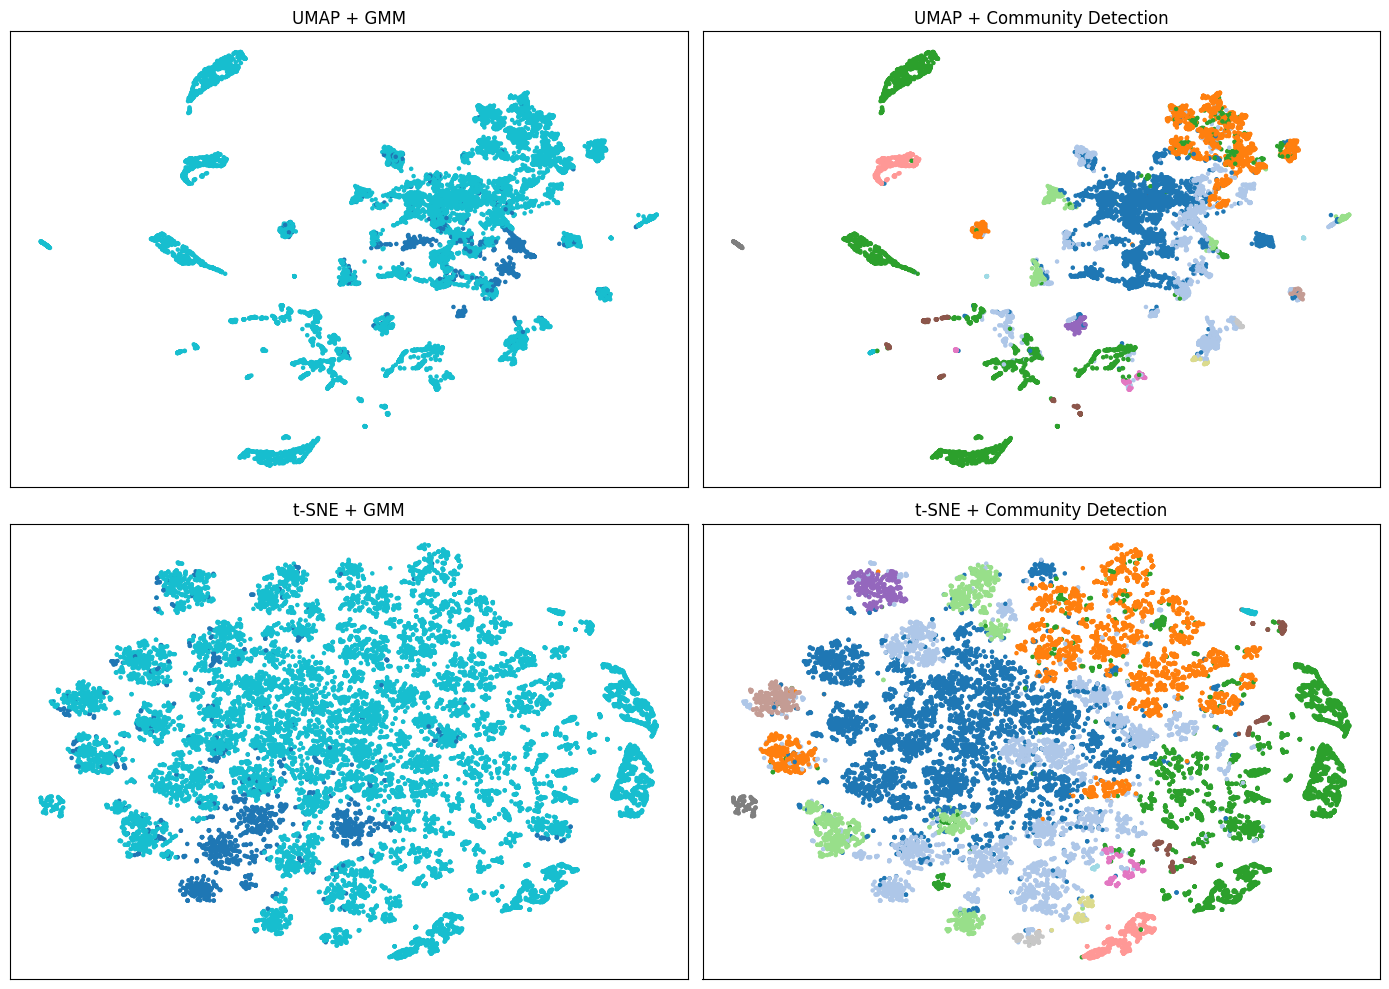

In [4]:
umap_xy = umap.UMAP(n_neighbors=30, min_dist=0.1, metric='euclidean', random_state=42).fit_transform(embed_sample)
tsne_xy = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=42).fit_transform(embed_sample)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].scatter(umap_xy[:, 0], umap_xy[:, 1], c=gmm_labels_sample, s=5, cmap='tab10')
axes[0, 0].set_title('UMAP + GMM')
axes[0, 1].scatter(umap_xy[:, 0], umap_xy[:, 1], c=community_labels, s=5, cmap='tab20')
axes[0, 1].set_title('UMAP + Community Detection')
axes[1, 0].scatter(tsne_xy[:, 0], tsne_xy[:, 1], c=gmm_labels_sample, s=5, cmap='tab10')
axes[1, 0].set_title('t-SNE + GMM')
axes[1, 1].scatter(tsne_xy[:, 0], tsne_xy[:, 1], c=community_labels, s=5, cmap='tab20')
axes[1, 1].set_title('t-SNE + Community Detection')
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()

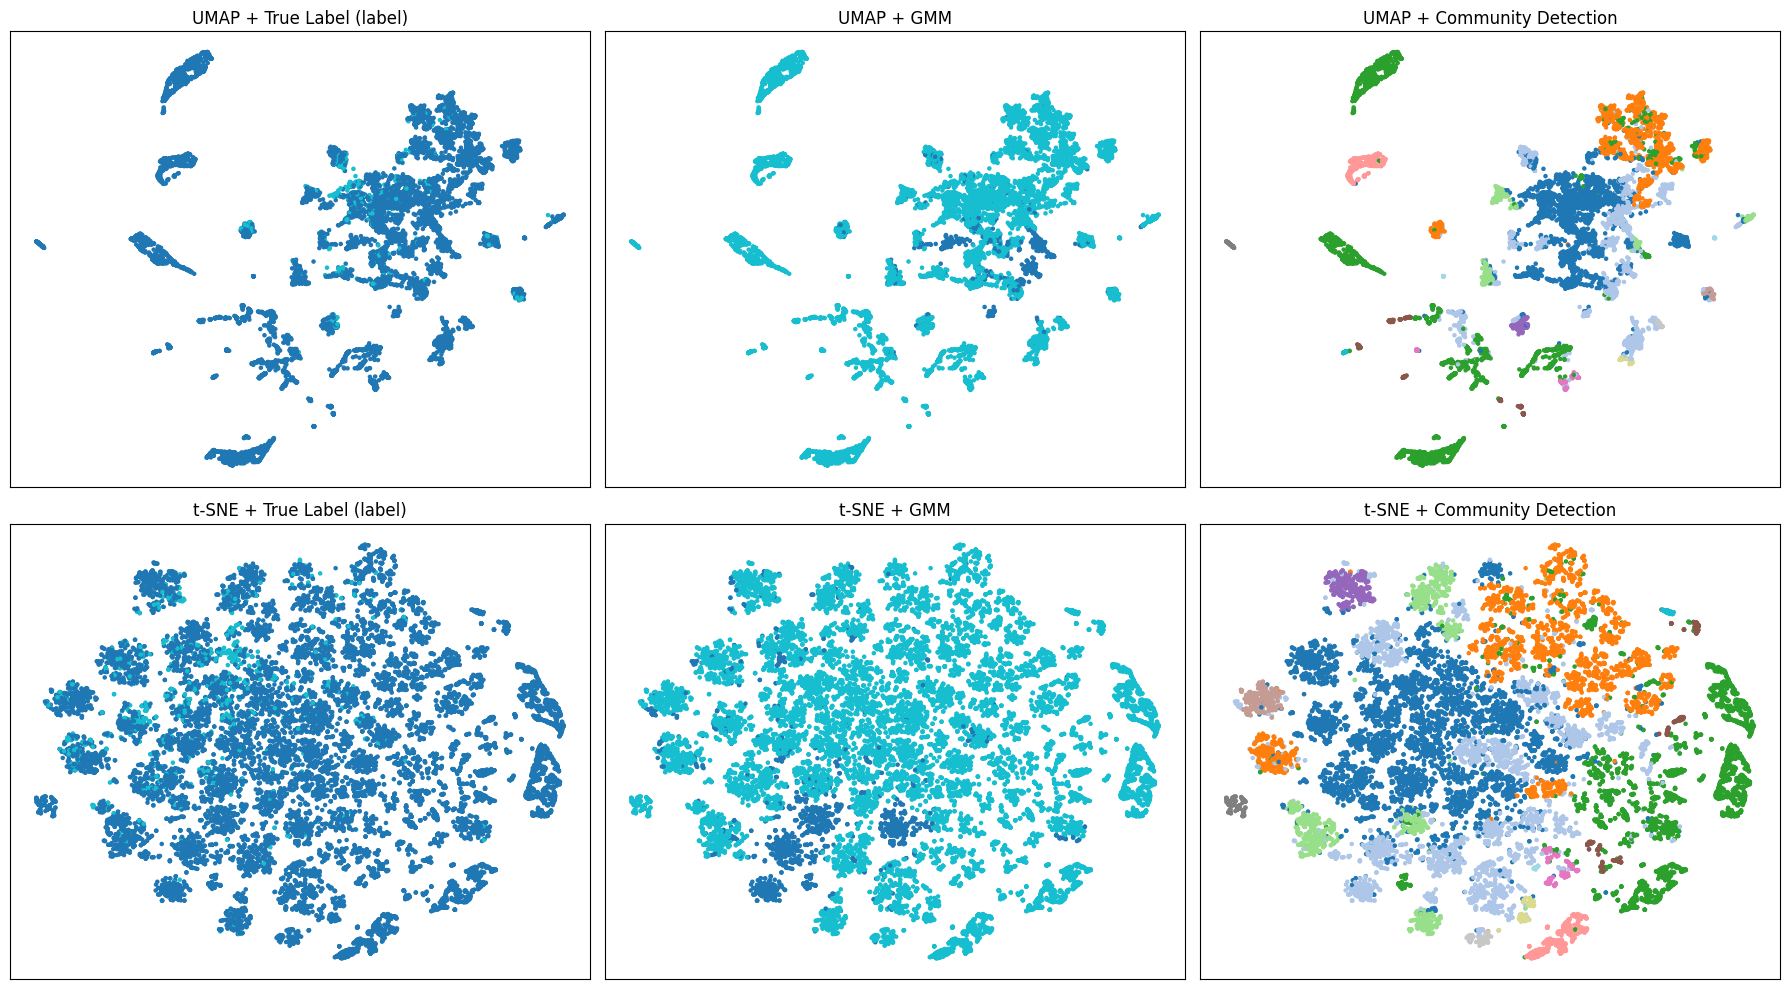

True label classes: ['- 50000.', '50000+.']


In [5]:
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np

# true label from the last column, aligned with the sampled rows
y_sample = df.iloc[sample_idx][target_col].astype(str)

# encode string labels to integers so matplotlib can color them
le = LabelEncoder()
y_true_encoded = le.fit_transform(y_sample)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: UMAP
axes[0, 0].scatter(umap_xy[:, 0], umap_xy[:, 1], c=y_true_encoded, s=5, cmap='tab10')
axes[0, 0].set_title(f'UMAP + True Label ({target_col})')

axes[0, 1].scatter(umap_xy[:, 0], umap_xy[:, 1], c=gmm_labels_sample, s=5, cmap='tab10')
axes[0, 1].set_title('UMAP + GMM')

axes[0, 2].scatter(umap_xy[:, 0], umap_xy[:, 1], c=community_labels, s=5, cmap='tab20')
axes[0, 2].set_title('UMAP + Community Detection')

# Row 2: t-SNE
axes[1, 0].scatter(tsne_xy[:, 0], tsne_xy[:, 1], c=y_true_encoded, s=5, cmap='tab10')
axes[1, 0].set_title(f't-SNE + True Label ({target_col})')

axes[1, 1].scatter(tsne_xy[:, 0], tsne_xy[:, 1], c=gmm_labels_sample, s=5, cmap='tab10')
axes[1, 1].set_title('t-SNE + GMM')

axes[1, 2].scatter(tsne_xy[:, 0], tsne_xy[:, 1], c=community_labels, s=5, cmap='tab20')
axes[1, 2].set_title('t-SNE + Community Detection')

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

print("True label classes:", list(le.classes_))


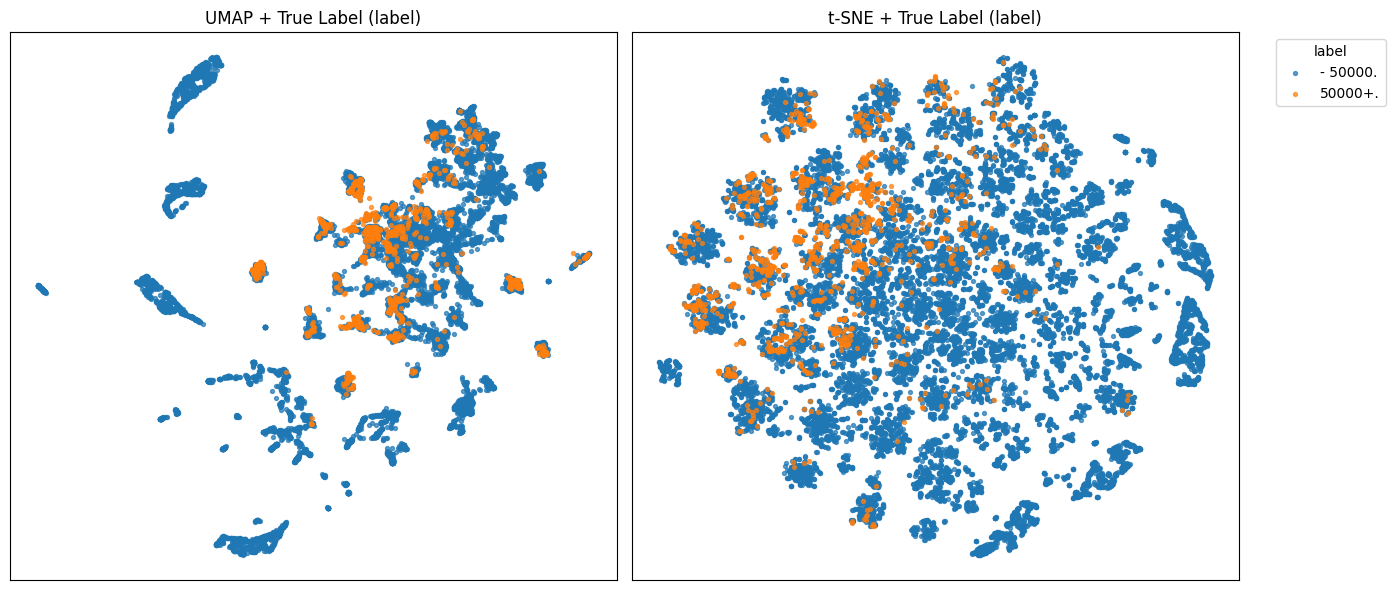

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for label_value in np.unique(y_true_encoded):
    mask = y_true_encoded == label_value
    axes[0].scatter(
        umap_xy[mask, 0], umap_xy[mask, 1],
        s=8, alpha=0.7, label=le.classes_[label_value]
    )
    axes[1].scatter(
        tsne_xy[mask, 0], tsne_xy[mask, 1],
        s=8, alpha=0.7, label=le.classes_[label_value]
    )

axes[0].set_title(f'UMAP + True Label ({target_col})')
axes[1].set_title(f't-SNE + True Label ({target_col})')

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

axes[1].legend(title=target_col, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
